# 2D Minimization Problem
In class we wanted to minimize the function $$x^2 + 2y^2$$ using constant step size, exact line search, and backtracking in order to compare the different methods. I used the AI function in Google Colab as directed by our professor to create the following code.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

First we will define the function, the gradient, and the three different methods we will use to minimize the function.

In [3]:
# Define the function and its gradient
def f(x):
    """
    Function to minimize: f(x, y) = x^2 + 2*y^2
    x is a numpy array [x_val, y_val]
    """
    return 100*x[0]**4 + 0.01 * x[1]**4

def nabla_f(x):
    """
    Gradient of the function: nabla_f(x, y) = [2x, 4y]
    x is a numpy array [x_val, y_val]
    """
    return np.array([2 * x[0], 4 * x[1]])

# Tolerance for convergence
TOL = 1e-6

# Initial point
x0 = np.array([1.0, 1.0])

print(f"Minimizing f(x, y) = x^2 + 2*y^2")
print(f"Starting point: {x0}")
print(f"Tolerance (gradient norm): {TOL}\n")


# --- 1. Gradient Descent with Constant Step Size ---
print("--- 1. Gradient Descent with Constant Step Size ---")
def constant_step_gd(x_start, alpha, tol, max_iter=10000):
    x = np.copy(x_start)
    path = [x.copy()] # Store the initial point
    for i in range(max_iter):
        grad = nabla_f(x)
        if np.linalg.norm(grad) < tol:
            break
        x_new = x - alpha * grad
        x = x_new
        path.append(x.copy())
    return np.array(path), i + 1

# For f(x) = x^2 + 2y^2, the Hessian is [[2,0],[0,4]]. Max eigenvalue is 4 (L constant for Lipschitz gradient).
# A safe step size is often 1/L = 1/4 = 0.25 for convergence.
alpha_const = 0.25
path_const, iters_const = constant_step_gd(x0, alpha_const, TOL)
x_const = path_const[-1]
print(f"Constant step size (alpha): {alpha_const}")
print(f"Converged at x: {x_const}")
print(f"Function value at x: {f(x_const)}")
print(f"Iterations: {iters_const}\n")


# --- 2. Gradient Descent with Exact Line Search ---
print("--- 2. Gradient Descent with Exact Line Search ---")
def exact_line_search_gd(x_start, tol, max_iter=10000):
    x = np.copy(x_start)
    path = [x.copy()] # Store the initial point
    for i in range(max_iter):
        grad = nabla_f(x)
        if np.linalg.norm(grad) < tol:
            break

        # Calculate optimal alpha for exact line search for f(x,y) = x^2 + 2y^2
        # alpha = (x_k0^2 + 4 * x_k1^2) / (2 * (x_k0^2 + 8 * x_k1^2))
        numerator = x[0]**2 + 4 * x[1]**2
        denominator = 2 * (x[0]**2 + 8 * x[1]**2)

        if denominator == 0: # This means x[0]=0 and x[1]=0, already at minimum
            alpha = 0
        else:
            alpha = numerator / denominator

        if alpha < 0: # Should not happen for this convex function, but as a safeguard
            alpha = 0

        x_new = x - alpha * grad
        x = x_new
        path.append(x.copy())
    return np.array(path), i + 1

path_exact, iters_exact = exact_line_search_gd(x0, TOL)
x_exact = path_exact[-1]
print(f"Converged at x: {x_exact}")
print(f"Function value at x: {f(x_exact)}")
print(f"Iterations: {iters_exact}\n")


# --- 3. Gradient Descent with Backtracking Line Search ---
print("--- 3. Gradient Descent with Backtracking Line Search ---")
def backtracking_line_search_gd(x_start, tol, max_iter=10000, alpha_init=1.0, rho=0.5, c=0.1):
    x = np.copy(x_start)
    path = [x.copy()] # Store the initial point
    for i in range(max_iter):
        grad = nabla_f(x)
        grad_norm = np.linalg.norm(grad)
        if grad_norm < tol:
            break

        alpha = alpha_init
        grad_norm_sq = grad_norm**2
        # Armijo condition: f(x - alpha * grad) <= f(x) - c * alpha * ||grad||^2
        while f(x - alpha * grad) > f(x) - c * alpha * grad_norm_sq:
            alpha *= rho
            if alpha < 1e-12: # Safeguard against tiny alpha causing stagnation
                break # Break inner while loop

        if alpha < 1e-12: # If alpha became too small, consider it converged or stuck
            break # Break outer for loop

        x_new = x - alpha * grad
        x = x_new
        path.append(x.copy())
    return np.array(path), i + 1

# Using common backtracking parameters
alpha_init_bt = 1.0
rho_bt = 0.5
c_bt = 0.1
path_backtracking, iters_backtracking = backtracking_line_search_gd(
    x0, TOL, alpha_init=alpha_init_bt, rho=rho_bt, c=c_bt
)
x_backtracking = path_backtracking[-1]
print(f"Backtracking parameters: alpha_init={alpha_init_bt}, rho={rho_bt}, c={c_bt}")
print(f"Converged at x: {x_backtracking}")
print(f"Function value at x: {f(x_backtracking)}")
print(f"Iterations: {iters_backtracking}\n")

Minimizing f(x, y) = x^2 + 2*y^2
Starting point: [1. 1.]
Tolerance (gradient norm): 1e-06

--- 1. Gradient Descent with Constant Step Size ---
Constant step size (alpha): 0.25
Converged at x: [4.76837158e-07 0.00000000e+00]
Function value at x: 5.169878828456423e-24
Iterations: 22

--- 2. Gradient Descent with Exact Line Search ---
Converged at x: [1.65195187e-07 1.65195187e-07]
Function value at x: 7.447885362708913e-26
Iterations: 13

--- 3. Gradient Descent with Backtracking Line Search ---
Backtracking parameters: alpha_init=1.0, rho=0.5, c=0.1
Converged at x: [ 0. -1.]
Function value at x: 0.01
Iterations: 2



Next we want to plot the optimization path of the function.

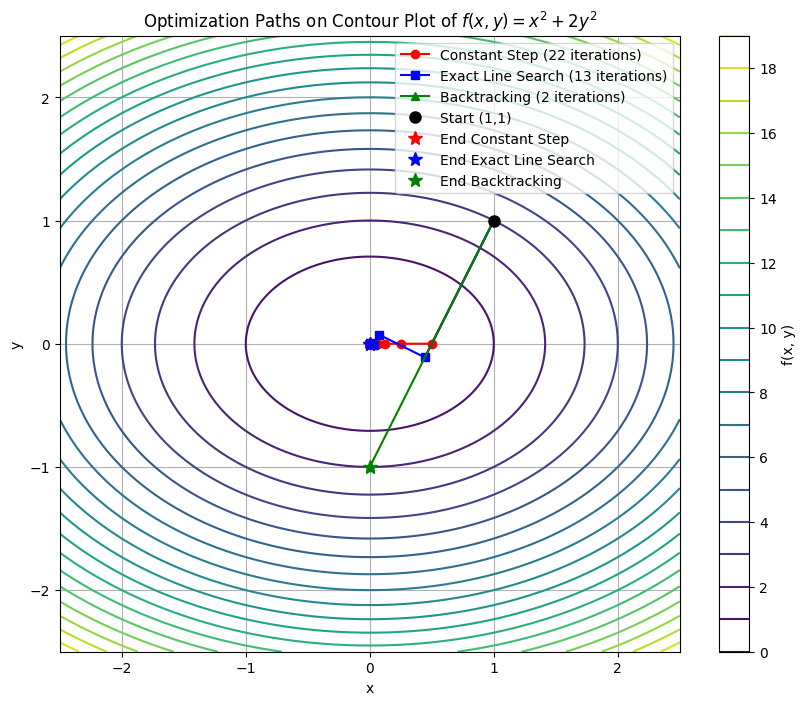

In [4]:
plt.figure(figsize=(10, 8))

# Create a meshgrid for the contour plot
x_vals = np.linspace(-2.5, 2.5, 400)
y_vals = np.linspace(-2.5, 2.5, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = X**2 + 2 * Y**2

# Plot the contour lines
plt.contour(X, Y, Z, levels=20, cmap='viridis')
plt.colorbar(label='f(x, y)')

# Plot the optimization paths
plt.plot(path_const[:, 0], path_const[:, 1], 'o-', color='red', label=f'Constant Step ({iters_const} iterations)')
plt.plot(path_exact[:, 0], path_exact[:, 1], 's-', color='blue', label=f'Exact Line Search ({iters_exact} iterations)')
plt.plot(path_backtracking[:, 0], path_backtracking[:, 1], '^-', color='green', label=f'Backtracking ({iters_backtracking} iterations)')

# Mark the starting point and the converged points
plt.plot(x0[0], x0[1], 'o', markersize=8, color='black', label='Start (1,1)')
plt.plot(x_const[0], x_const[1], '*', markersize=10, color='red', label='End Constant Step')
plt.plot(x_exact[0], x_exact[1], '*', markersize=10, color='blue', label='End Exact Line Search')
plt.plot(x_backtracking[0], x_backtracking[1], '*', markersize=10, color='green', label='End Backtracking')

# Add labels, title, and legend
plt.xlabel('x')
plt.ylabel('y')
plt.title('Optimization Paths on Contour Plot of $f(x, y) = x^2 + 2y^2$')
plt.legend()
plt.grid(True)
plt.show()